In [13]:
import pandas as pd        # pandas: work with tabular data (like Excel but in Python)
import sqlite3             # sqlite3: built-in Python library to talk to SQLite databases
import matplotlib.pyplot as plt   # matplotlib: draw charts and plots
import seaborn as sns      # seaborn: prettier statistical charts built on top of matplotlib

# Connect to the SQLite database file we created in fetch_neos.py
# This doesn't load all data yet — just opens a connection channel
conn = sqlite3.connect("asteroids.db")

# read_sql runs a SQL query and returns the result as a pandas DataFrame
# "SELECT * FROM neo_raw" means: give me every column and every row from neo_raw table
df = pd.read_sql("SELECT * FROM neo_raw", conn)

# Always close the connection when done — frees up the file lock
conn.close()

# SQLite has no real boolean type — it stored True/False as 1/0 integers
# astype(bool) converts: 1 → True, 0 → False so our logic works correctly later
df['is_hazardous'] = df['is_hazardous'].astype(bool)

# .shape returns (rows, columns) — quick sanity check that data loaded correctly
print(f"Shape: {df.shape}")

# .dtypes shows the data type of each column (int64, float64, object, bool etc.)
# Important: diameter_km should be float64, is_hazardous should be bool
print(f"\nColumn types:\n{df.dtypes}")

# .isnull().sum() counts missing values per column
# We want all zeros here — any missing value in diameter/velocity = problem for ML later
print(f"\nMissing values:\n{df.isnull().sum()}")

Shape: (34, 8)

Column types:
id                   str
name                 str
diameter_km      float64
is_hazardous        bool
velocity_kps     float64
miss_dist_km     float64
approach_date        str
magnitude_h      float64
dtype: object

Missing values:
id               0
name             0
diameter_km      0
is_hazardous     0
velocity_kps     0
miss_dist_km     0
approach_date    0
magnitude_h      0
dtype: int64


In [14]:
# value_counts() counts how many rows have each unique value in is_hazardous
# Result looks like:  False → 27,  True → 7  (for example)
counts = df['is_hazardous'].value_counts()

print("Class distribution:")

# counts[False] = number of non-hazardous asteroids
# counts[False]/len(df)*100 = percentage of total — e.g. 27/34*100 = 79.4%
print(f"  Not hazardous : {counts[False]}  ({counts[False]/len(df)*100:.1f}%)")

# counts[True] = number of hazardous asteroids
# :.1f means format the float to 1 Zdecimal place — so 20.588... becomes 20.6%
print(f"  Hazardous     : {counts[True]}   ({counts[True]/len(df)*100:.1f}%)")

# WHY THIS MATTERS: if only 20% are hazardous, our ML model is "imbalanced"
# A dumb model that always says "not hazardous" would be 80% accurate but useless
# In Week 2 we'll use class_weight or scale_pos_weight to fix this

Raw value counts (checking types):
is_hazardous
False    27
True      7
Name: count, dtype: int64

Index values: [False, True]

Class distribution (after fix):
  Not hazardous : 27  (79.4%)
  Hazardous     : 7   (20.6%)


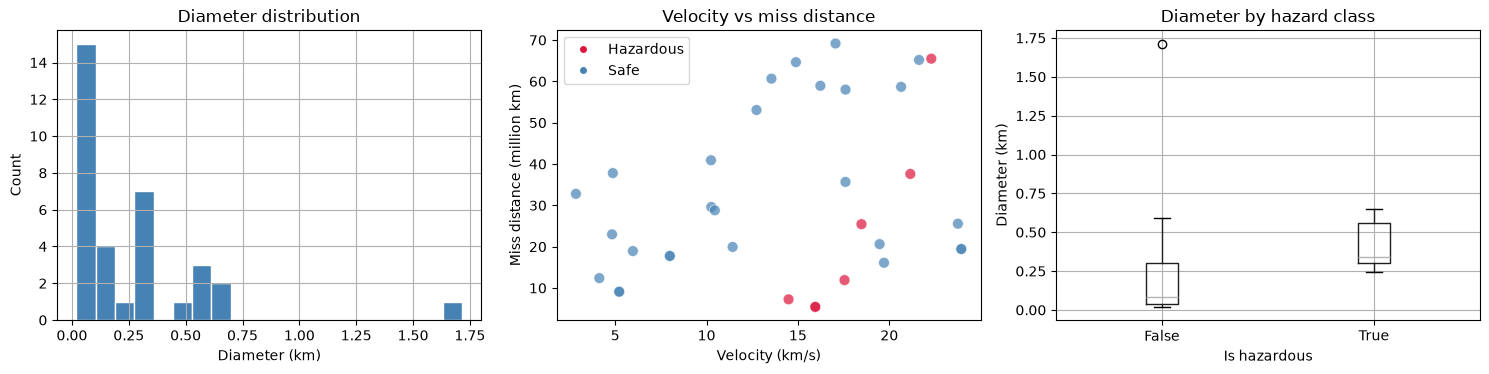

Saved eda_plots.png


In [15]:
# Create a figure with 3 side-by-side subplots
# figsize=(15, 4) means 15 inches wide, 4 inches tall
# axes is a list of 3 Axes objects: axes[0], axes[1], axes[2]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))


# ── Plot 1: Diameter distribution ─────────────────────────────────
# .hist() draws a histogram — groups values into bins and counts how many fall in each
# bins=20 means divide the range into 20 equal buckets
# edgecolor='white' draws a thin white border between bars so they're easier to read
df['diameter_km'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Diameter distribution')
axes[0].set_xlabel('Diameter (km)')
axes[0].set_ylabel('Count')
# WHAT TO LOOK FOR: most asteroids will be tiny (<0.5 km), a few large outliers
# If the histogram is very right-skewed, we'll use log scale in Week 2


# ── Plot 2: Velocity vs miss distance scatter ──────────────────────
# Map is_hazardous boolean to a color: True → red, False → blue
# This creates a Series of color strings aligned with each row
colors = df['is_hazardous'].map({True: 'crimson', False: 'steelblue'})

# scatter() plots one dot per asteroid
# x-axis = velocity, y-axis = miss distance (divided by 1e6 to show millions of km)
# alpha=0.7 makes dots slightly transparent so overlapping ones are visible
# s=60 is the dot size in points²
axes[1].scatter(df['velocity_kps'], df['miss_dist_km'] / 1e6,
                c=colors, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)
axes[1].set_xlabel('Velocity (km/s)')
axes[1].set_ylabel('Miss distance (million km)')
axes[1].set_title('Velocity vs miss distance')

# Manually build a legend since we used raw colors instead of seaborn's auto-legend
# Line2D creates a dummy marker just for the legend — it's not drawn on the chart
axes[1].legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='crimson', label='Hazardous'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', label='Safe')
])
# WHAT TO LOOK FOR: red dots (hazardous) should cluster at smaller miss distances
# That would confirm miss_distance is a strong predictive feature


# ── Plot 3: Diameter boxplot by hazard class ───────────────────────
# boxplot() shows median, quartiles, and outliers for each group
# by='is_hazardous' splits into two boxes: one for False, one for True
# column='diameter_km' is the value being compared
df.boxplot(column='diameter_km', by='is_hazardous', ax=axes[2])
axes[2].set_title('Diameter by hazard class')
axes[2].set_xlabel('Is hazardous')
axes[2].set_ylabel('Diameter (km)')
plt.suptitle('')   # pandas adds an ugly default title — this removes it
# WHAT TO LOOK FOR: the True box should sit higher than False
# If hazardous asteroids are consistently larger, diameter is a strong ML feature


# tight_layout() automatically adjusts spacing so labels don't overlap each other
plt.tight_layout()

# Save the figure as a PNG file in your project folder
# dpi=120 means 120 dots per inch — crisp enough for a GitHub README screenshot
# bbox_inches='tight' crops out any extra whitespace around the edges
plt.savefig('eda_plots.png', dpi=120, bbox_inches='tight')

plt.show()   # actually render the plots in the notebook
print("Saved eda_plots.png")

In [16]:
# groupby('is_hazardous') splits the DataFrame into two groups:
#   group False = all non-hazardous rows
#   group True  = all hazardous rows

# [['diameter_km','velocity_kps','miss_dist_km']] selects only these 3 columns
# because id, name, approach_date aren't numeric and don't make sense to average

# .agg(['mean','median','max']) computes all 3 statistics for each column in each group
# mean   = average value
# median = middle value (less affected by extreme outliers than mean)
# max    = highest value seen

# .round(3) rounds all numbers to 3 decimal places for clean display
print("Summary stats by hazard class:\n")
print(df.groupby('is_hazardous')[['diameter_km','velocity_kps','miss_dist_km']]\
        .agg(['mean','median','max'])\
        .round(3))

# HOW TO READ THE OUTPUT:
# Rows:    False = non-hazardous group,  True = hazardous group
# Columns: each metric (diameter_km, velocity_kps, miss_dist_km)
#          with sub-columns mean / median / max
#
# KEY INSIGHT TO LOOK FOR:
#   If hazardous mean diameter >> non-hazardous mean diameter → diameter is a strong feature
#   If hazardous mean miss_dist << non-hazardous mean miss_dist → miss distance is a strong feature
#   If velocity means are similar between groups → velocity alone is a weak feature
#   These insights directly tell us which columns will matter most in the XGBoost model

Summary stats by hazard class:

             diameter_km               velocity_kps                  \
                    mean median    max         mean  median     max   
is_hazardous                                                          
False              0.218  0.082  1.714       13.118  12.731  23.937   
True               0.422  0.344  0.649       17.980  17.549  22.298   

              miss_dist_km                              
                      mean        median           max  
is_hazardous                                            
False         3.418459e+07  2.879378e+07  6.916148e+07  
True          2.264912e+07  1.191004e+07  6.548912e+07  
